#  Metabolic Syndrome: Understanding and Predicting Diabetes Risk.

**The Scenario** <br>

You are a Clinical Researcher at the Federal Medical Center (FMC) Asaba. You are conducting a study on Metabolic Syndrome, a cluster of conditions that occur together, increasing the risk of heart disease, stroke, and type 2 diabetes.<br>
You have a dataset of 500 adult patients, but the data is messy.
Your Goal: Clean the data, prove statistical relationships between vitals (using Biostatistics), and finally, build a model (AI) tool to predict if a patient has Diabetes.

**First We import all the libraries we will need**

Ensure you installed the libraries in your activated environment. If not, activate environment in another terminal and install the dependencies

Eg: pip install pandas numpy seaborn matplotlib scipy scikit-learn imbalanced-learn joblib   

Or pip install -r requirements.txt


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


## Export Data as csv code demo

In [ ]:
# # Export the DataFrame to a CSV file
# df.to_csv('patient_data.csv', index=False)

# print("Data exported successfully to 'patient_data.csv'")

## Import data from a csv file

In [ ]:
# Import the data back into a new DataFrame
df = pd.read_csv('./dataset/patient_data.csv')

# Verify the import
print("Data imported successfully. Here are the first 5 rows:")
print(df.head())
df.head()

Data imported successfully. Here are the first 5 rows:
  Patient_ID  Age  Gender Smoking_Status Physical_Activity        BMI  \
0     FMC000   68    Male            Yes          Moderate  35.382702   
1     FMC001   58    Male             No              High  34.900457   
2     FMC002   44  Female            Yes          Moderate  24.872186   
3     FMC003   72  Female             No              High  29.979018   
4     FMC004   37    Male            Yes               Low  30.470151   

   Fasting_Blood_Sugar Blood_Pressure  Diabetes_Diagnosis  Systolic_BP  \
0           119.152007         106/71                   1          106   
1           130.673331         122/83                   1          122   
2            97.496148         120/76                   0          120   
3            94.908156         128/82                   0          128   
4            78.050435         121/72                   0          121   

   Diastolic_BP  
0            71  
1            83  
2      

,Patient_ID,Age,Gender,Smoking_Status,Physical_Activity,BMI,Fasting_Blood_Sugar,Blood_Pressure,Diabetes_Diagnosis,Systolic_BP,Diastolic_BP
0,FMC000,68,Male,Yes,Moderate,35.382702,119.152007,106/71,1,106,71
1,FMC001,58,Male,No,High,34.900457,130.673331,122/83,1,122,83
2,FMC002,44,Female,Yes,Moderate,24.872186,97.496148,120/76,0,120,76
3,FMC003,72,Female,No,High,29.979018,94.908156,128/82,0,128,82
4,FMC004,37,Male,Yes,Low,30.470151,78.050435,121/72,0,121,72


**To get the last 5 rows** 

In [ ]:
df.tail()

,Patient_ID,Age,Gender,Smoking_Status,Physical_Activity,BMI,Fasting_Blood_Sugar,Blood_Pressure,Diabetes_Diagnosis,Systolic_BP,Diastolic_BP
495,FMC495,42,Male,No,High,25.714519,103.808872,119/81,0,119,81
496,FMC496,41,Male,No,Moderate,24.988940,79.439502,156/69,0,156,69
497,FMC497,60,Male,Yes,Moderate,30.343871,128.025767,119/70,1,119,70
498,FMC498,31,Female,No,Low,23.008073,100.005177,152/86,0,152,86
499,FMC499,64,Female,No,High,29.508959,99.767492,133/92,0,133,92


**To get the secified number of rows**

In [ ]:
df.head(30)

,Patient_ID,Age,Gender,Smoking_Status,Physical_Activity,BMI,Fasting_Blood_Sugar,Blood_Pressure,Diabetes_Diagnosis,Systolic_BP,Diastolic_BP
0,FMC000,68,Male,Yes,Moderate,35.382702,119.152007,106/71,1,106,71
1,FMC001,58,Male,No,High,34.900457,130.673331,122/83,1,122,83
2,FMC002,44,Female,Yes,Moderate,24.872186,97.496148,120/76,0,120,76
3,FMC003,72,Female,No,High,29.979018,94.908156,128/82,0,128,82
4,FMC004,37,Male,Yes,Low,30.470151,78.050435,121/72,0,121,72
5,FMC005,50,Female,No,Moderate,29.303369,79.327991,123/96,0,123,96
6,FMC006,68,Female,No,High,25.248474,94.338028,134/89,0,134,89
7,FMC007,48,Female,No,High,24.641883,109.184138,108/80,0,108,80
8,FMC008,52,Female,No,Low,27.872230,122.839616,136/97,0,136,97
9,FMC009,40,Female,No,Moderate,33.863645,79.920526,142/80,0,142,80


**To print all rows**

In [ ]:
# pd.set_option('display.max_rows', None)
# df

## Step 1: Data Ingestion & Pre-Analytical Cleaning

In [ ]:
print("--- 1. Checking for Missing Data ---")
print(df.isnull().sum()) # This checks for rows that contain null values

--- 1. Checking for Missing Data ---
Patient_ID             0
Age                    0
Gender                 0
Smoking_Status         0
Physical_Activity      0
BMI                    0
Fasting_Blood_Sugar    0
Blood_Pressure         0
Diabetes_Diagnosis     0
Systolic_BP            0
Diastolic_BP           0
dtype: int64


In [ ]:
# A. Imputation: Fill missing Fasting Blood Sugar with the Median value. Even though There are no null values,
# We are doing this in case futures records  when added to the databse and contain null values, this step 
# prevents our programme from breaking.

# We use median here beacuse mean is sensitive to outliers for Fasting_Blood_sugar, while median gives 
# a realisting value for a patient

median_fbs = df['Fasting_Blood_Sugar'].median()
df['Fasting_Blood_Sugar'] = df['Fasting_Blood_Sugar'].fillna(median_fbs)

## Next we want to 

B. Standardize Text: Clean the Smoking_Status column Convert 'Y', 'yes' to 'Yes' and 'N', 'no' to 'No'

In [ ]:
# We will do this anyway even though it is well structured in our dataset as part of our defensive programming
# to prevent a break in our programme in future due to dirty or inconsistent data

df['Smoking_Status'] 

0      Yes
1       No
2      Yes
3       No
4      Yes
      ... 
495     No
496     No
497    Yes
498     No
499     No
Name: Smoking_Status, Length: 500, dtype: object

In [ ]:

df['Smoking_Status'] = df['Smoking_Status'].replace({'Y': 'Yes', 'yes': 'Yes', 'N': 'No', 'no': 'No'})

In [ ]:
df.dtypes

Patient_ID              object
Age                      int64
Gender                  object
Smoking_Status          object
Physical_Activity       object
BMI                    float64
Fasting_Blood_Sugar    float64
Blood_Pressure          object
Diabetes_Diagnosis       int64
Systolic_BP              int64
Diastolic_BP             int64
dtype: object

In [ ]:
df['Smoking_Status'] = df['Smoking_Status'].astype(str)
print(type(df['Smoking_Status'].iloc[0])) # prints the datatpe of the first item in the Smoking_Status column
df.dtypes

<class 'str'>


Patient_ID              object
Age                      int64
Gender                  object
Smoking_Status          object
Physical_Activity       object
BMI                    float64
Fasting_Blood_Sugar    float64
Blood_Pressure          object
Diabetes_Diagnosis       int64
Systolic_BP              int64
Diastolic_BP             int64
dtype: object

In [ ]:
# C. Split Strings: Separate '130/85' into Systolic and Diastolic integers

df[['Systolic_BP', 'Diastolic_BP']] = df['Blood_Pressure'].str.split('/', expand=True)

# We then covert the datatype for Sytolic_BP and Diastolic_BP to numeric data just incase
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'])
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'])

print("\n Data Cleaned Successfully. Ready for Analysis.")
df.dtypes


 Data Cleaned Successfully. Ready for Analysis.


Patient_ID              object
Age                      int64
Gender                  object
Smoking_Status          object
Physical_Activity       object
BMI                    float64
Fasting_Blood_Sugar    float64
Blood_Pressure          object
Diabetes_Diagnosis       int64
Systolic_BP              int64
Diastolic_BP             int64
dtype: object

## Step 2: Exploratory Data Analysis (The Clinical Picture)

EDA is how we look at the data to see what the population looks like.

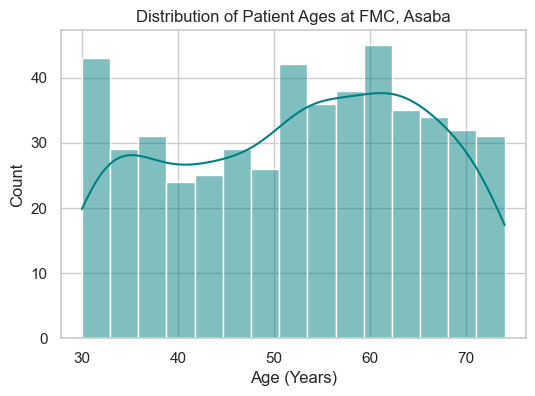

In [ ]:
# Set a beautiful theme for our medical charts
sns.set_theme(style="whitegrid")

# Visual 1: The Patient Demographic (Histogram)
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], bins=15, kde=True, color='teal')
plt.title('Distribution of Patient Ages at FMC, Asaba')
plt.xlabel('Age (Years)')
plt.show()

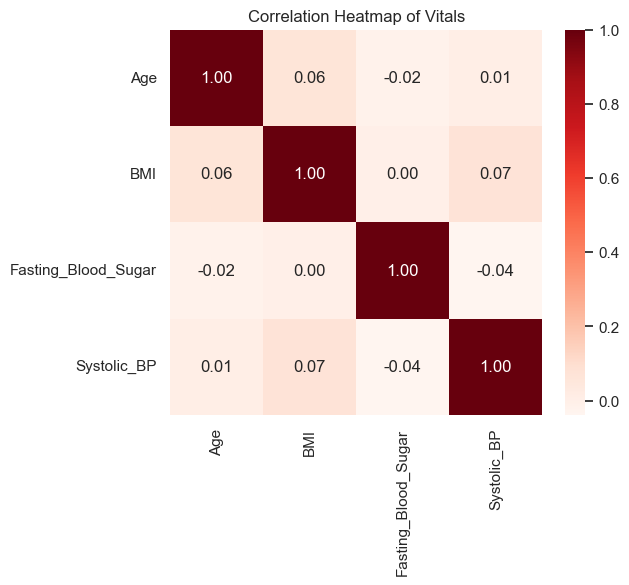

In [ ]:
# Visual 2: The Heatmap (Finding Correlations)
# We only want to correlate numbers, so we select numeric columns

numeric_cols = df[['Age', 'BMI', 'Fasting_Blood_Sugar', 'Systolic_BP']]
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Correlation Heatmap of Vitals')
plt.show()

### Interpretation of the Heatmap:
A correlation heatmap is a graphical representation of how strongly different variables (in this case, health vitals) are related to each other. 

The Variables: The chart analyzes four health metrics: Age, BMI (Body Mass Index), Fasting_Blood_Sugar, and Systolic_BP.<br>
The Numbers: Each square contains a correlation coefficient ranging from 0 to 1.<br>
The Colors: The color intensity represents the strength of the relationship. Darker colors indicate a stronger positive correlation.
     

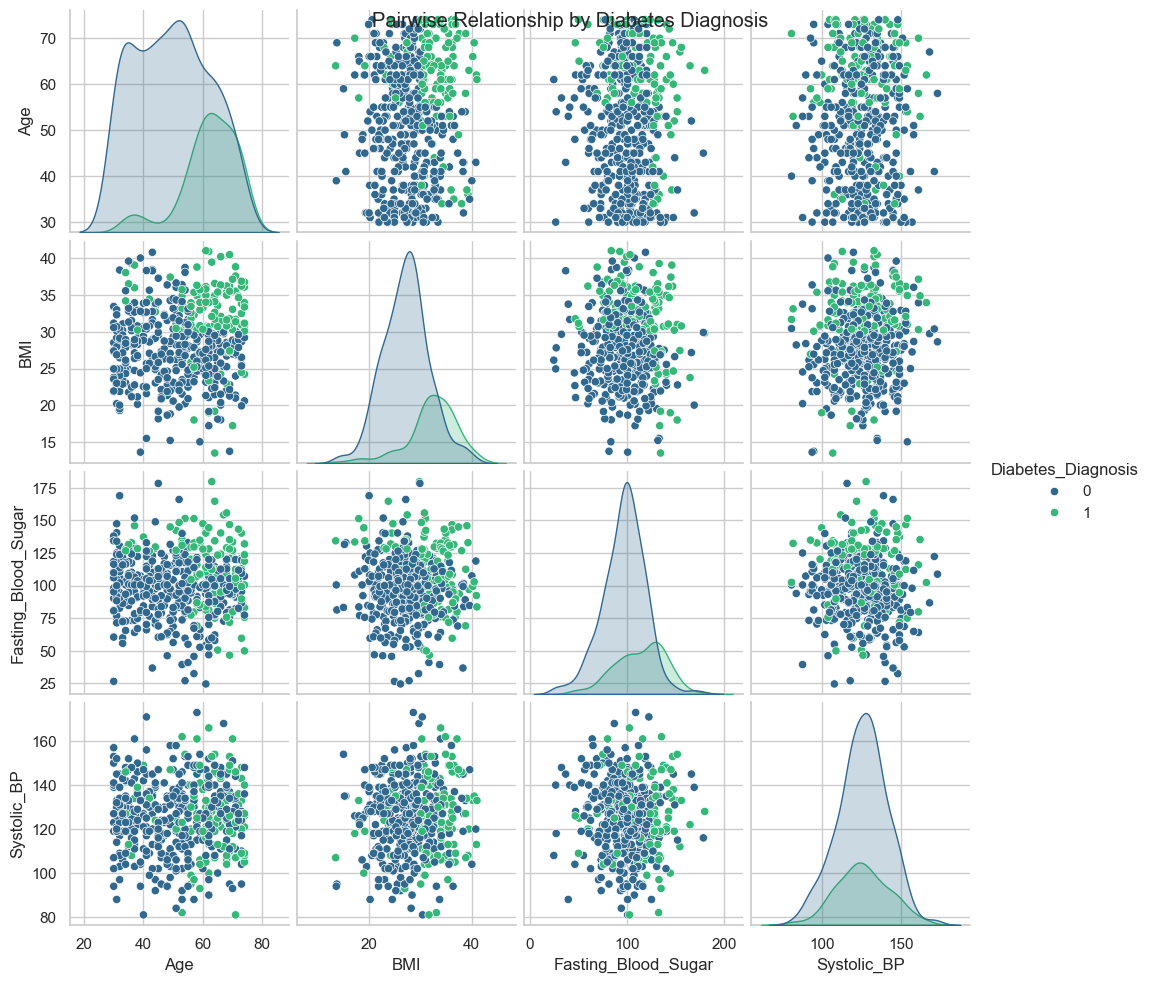

In [ ]:
# Visual 3: Pairplot

sns.pairplot(df[['Age', 'BMI', 'Fasting_Blood_Sugar', 'Systolic_BP', 'Diabetes_Diagnosis']], 
             hue='Diabetes_Diagnosis', palette='viridis')

plt.suptitle('Pairwise Relationship by Diabetes Diagnosis')
plt.show()

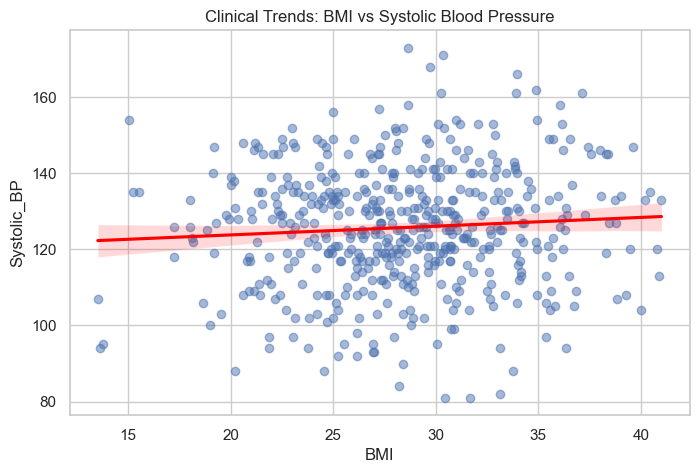

In [ ]:
# Visual 4: Regression Plot

plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='BMI', y='Systolic_BP', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Clinical Trends: BMI vs Systolic Blood Pressure')
plt.show()

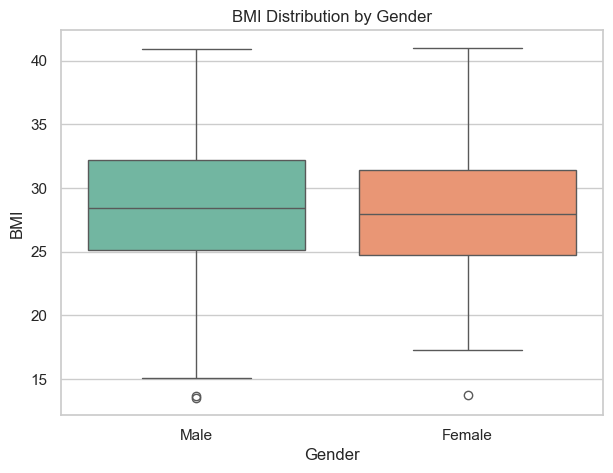

In [ ]:
# Visual 5: Box Plot. (Gender vs BMI)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Gender', y='BMI', palette='Set2', hue='Gender', legend=False )
plt.title('BMI Distribution by Gender')
plt.show()

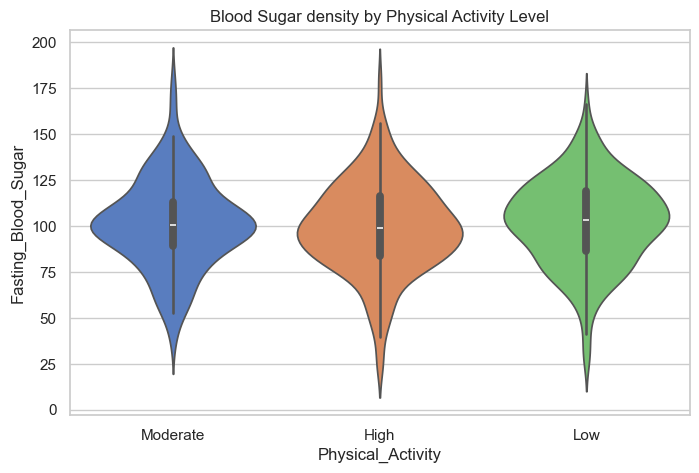

In [ ]:
# Visual 6: Violine Plot (Activity Level vs Blood Sugar)

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Physical_Activity', y='Fasting_Blood_Sugar', palette='muted', hue='Physical_Activity', legend=False)
plt.title('Blood Sugar density by Physical Activity Level')
plt.show()

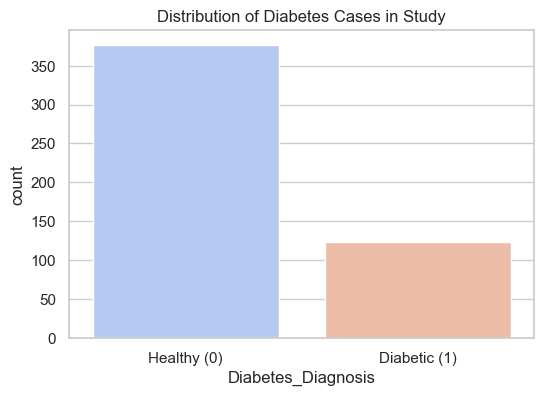

In [ ]:
# Visual 7: Count Plot(To check the Healthy and Diabetic) 
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Diabetes_Diagnosis', hue='Diabetes_Diagnosis', palette='coolwarm', legend=False)
plt.xticks([0, 1], ['Healthy (0)', 'Diabetic (1)'])
plt.title('Distribution of Diabetes Cases in Study')
plt.show()

**Our Dataset Apears imbalanced**<br>
This class imbalance can cause our model to be biased toward predicting "Healthy" because it is the majority class. For a solution to this, we have several strategies, namely:



1. **SMOTE (Synthetic Minority Over-sampling Technique)** - Creates synthetic samples of the minority class
2. **Class Weights** - Tells the model to pay more attention to the minority class
3. **Undersampling** - Reduces the majority class to match the minority class

For this demo, we will use **Class Weights** beacuse it is simplest and most effective for starting.



## **Step 3: Biostatistics Part 1 (Normality Testing)**

Concept: In research, before you run standard tests (like a T-Test), you should prove your data follows a normal "bell curve". We use the Shapiro-Wilk Test.

    Null Hypothesis (H0): The data IS normally distributed.

    Rule: If p-value > 0.05, we accept the Null (It is normal), else we reject the null hypothesis.

In [ ]:
# We will test the 'Systolic_BP' column
stat, p_value = stats.shapiro(df['Systolic_BP'])

print("--- Shapiro-Wilk Test for Normality ---")
print(f"P-Value: {p_value:.4f}")

if p_value > 0.05:
    print("Interpretation: p > 0.05. The Blood Pressure data IS normally distributed. We can proceed with T-Tests.")
else:
    print("Interpretation: p < 0.05. The data is Skewed. (Use non-parametric tests instead).")

--- Shapiro-Wilk Test for Normality ---
P-Value: 0.4122
Interpretation: p > 0.05. The Blood Pressure data IS normally distributed. We can proceed with T-Tests.


## Step 4: Biostatistics Part 2 (Hypothesis Testing)

Is a difference real, or just by chance? <br>
Test A: Independent T-Test (Comparing 2 Groups) <br>

Question: Is there a significant difference in BMI between Male and Female patients?

In [ ]:
males = df[df['Gender'] == 'Male']['BMI']
females = df[df['Gender'] == 'Female']['BMI']

# Run the T-Test
t_stat, p_val = stats.ttest_ind(males, females)

print("--- T-Test: BMI by Gender ---")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Interpretation: p < 0.05. There IS a statistically significant difference in BMI between genders.")
else:
    print("Interpretation: p > 0.05. NO significant difference. Any difference seen is likely due to chance.")

--- T-Test: BMI by Gender ---
P-Value: 0.5652
Interpretation: p > 0.05. NO significant difference. Any difference seen is likely due to chance.


### Test B: ANOVA (Comparing 3+ Groups)

**Question: Does Fasting Blood Sugar differ based on Physical Activity level (Low, Moderate, High)?**

In [ ]:
low_act = df[df['Physical_Activity'] == 'Low']['Fasting_Blood_Sugar']
mod_act = df[df['Physical_Activity'] == 'Moderate']['Fasting_Blood_Sugar']
high_act = df[df['Physical_Activity'] == 'High']['Fasting_Blood_Sugar']

# Run the ANOVA (Analysis of Variance)
f_stat, p_val_anova = stats.f_oneway(low_act, mod_act, high_act)

print("\n--- ANOVA: Blood Sugar by Physical Activity ---")
print(f"P-Value: {p_val_anova:.4f}")

if p_val_anova < 0.05:
    print("Interpretation: Activity level significantly affects Blood Sugar.")
else:
    print("Interpretation: Activity level does not significantly affect Blood Sugar in this dataset.")


--- ANOVA: Blood Sugar by Physical Activity ---
P-Value: 0.5171
Interpretation: Activity level does not significantly affect Blood Sugar in this dataset.


## Test C: Linear Regression (Predicting a Number)

**Question: How much does BMI directly affect Systolic_BP?**

In [ ]:
# Run Linear Regression using Scipy
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(df['BMI'], df['Systolic_BP'])

print("\n--- Linear Regression: BMI vs Systolic BP ---")
print(f"R-squared (Accuracy of trend): {(r_value**2):.3f}")
print(f"P-Value: {p_value_reg:.4f}")
print(f"Slope (Coefficient): {slope:.2f}")
print(f"Interpretation: For every 1 unit increase in BMI, Systolic BP changes by {slope:.2f} mmHg.")


--- Linear Regression: BMI vs Systolic BP ---
R-squared (Accuracy of trend): 0.005
P-Value: 0.0986
Slope (Coefficient): 0.23
Interpretation: For every 1 unit increase in BMI, Systolic BP changes by 0.23 mmHg.


## Feature Engineering 

The process of selecting, modifying, or creating features (variables) that improve the performance of machine learning models.

New Features Created:
  Age_Group  Hypertension  Obesity  Pre_Diabetes
0   Elderly             0        1             1
1    Senior             0        1             0
2    Middle             0        0             0
3   Elderly             0        0             0
4    Middle             0        1             0
5    Senior             1        0             0
6   Elderly             0        0             0
7    Senior             0        0             1
8    Senior             1        0             1
9    Middle             1        1             0


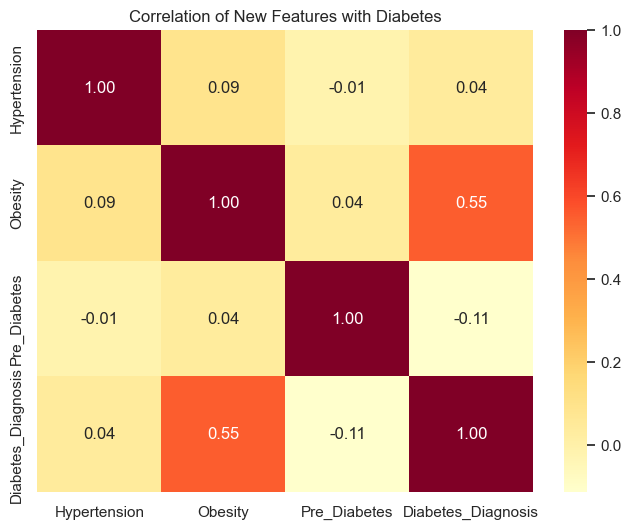

In [ ]:
# Feature Engineering (Creating Better Predictors)

# Create new clinically relevant features
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], labels=['Young', 'Middle', 'Senior', 'Elderly'])

# Hypertension Risk (BP > 140/90)
df['Hypertension'] = ((df['Systolic_BP'] > 140) | (df['Diastolic_BP'] > 90)).astype(int)

# Obesity Risk (BMI >= 30)
df['Obesity'] = (df['BMI'] >= 30).astype(int)

# Pre-diabetes Range (FBS 100-125)
df['Pre_Diabetes'] = ((df['Fasting_Blood_Sugar'] >= 100) & (df['Fasting_Blood_Sugar'] < 126)).astype(int)

print("New Features Created:")
print(df[['Age_Group', 'Hypertension', 'Obesity', 'Pre_Diabetes']].head(10))

# Check correlation of new features with Diabetes
plt.figure(figsize=(8, 6))
new_features = ['Hypertension', 'Obesity', 'Pre_Diabetes']
corr_matrix = df[new_features + ['Diabetes_Diagnosis']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Correlation of New Features with Diabetes')
plt.show()

### Step 5: Machine Learning (Building a Predictive model )

Biostatistics told us the "Why" (Relationships). Machine Learning will give us the "What's Next" (Predictions).<br>

Goal: Build a Logistic Regression  model (AI) to predict if a new patient has Diabetes (1 = Yes, 0 = No).

5.1 Train/Test Split

## What is Machine Learning?


Machine Learning is a branch of Artificial Intelligence (AI) where computers learn from data to make predictions or decisions without being explicitly programmed for every rule. 

In Healthcare: Instead of a doctor manually writing code to say "If Blood Sugar > 126, then Diabetes," we feed an algorithm thousands of patient records. The algorithm learns the patterns (which might be more complex than a single number) and predicts diabetes risk automatically.
     

**2. Types of Machine Learning** 

There are three main types, but for your current project, Supervised Learning is the most important. 

**Supervised Learning:** The computer learns from labeled data. This means the "correct answer" is already known in the historical data.

Example: You have patient data (Age, BMI) and you already know who has Diabetes (the label). The model learns to map the inputs to the label.

Tasks:

**Classification:** Predicting a category (e.g., "Diabetic" vs. "Non-Diabetic").

**Regression:** Predicting a continuous number (e.g., predicting exact "Length of Hospital Stay" in days).
             
         
**Unsupervised Learning:** The computer learns from unlabeled data. It finds hidden patterns or groupings without being told the "right answer."
    
Example: Grouping patients into distinct "clusters" based on similar symptoms without knowing what those groups represent beforehand.
         
**Reinforcement Learning:** Learning by trial and error to maximize a reward (often used in robotics or treatment dosing strategies).
     

**3. Modeling** 

Modeling is the process of selecting a mathematical algorithm and training it on your data. 

**Training:** The model looks at the input features (Age, BMI, BP) and the target (Diabetes_Diagnosis). It adjusts its internal math to minimize errors.

**Testing:** After training, you give the model "new" data (data it hasn't seen before) to see if it can accurately predict the outcome.

**Common Algorithms:**

**Logistic Regression:** Good for simple binary classification (Yes/No).

**Decision Trees:** Flowchart-like structures (e.g., "Is BMI > 30? -> Yes -> Is Age > 50?").

R**andom Forest:** A collection of decision trees (more accurate).
         

**4. Model Evaluation** 

Once a model is built, you must measure how well it performs. In healthcare, accuracy alone is often not enough. 

**Accuracy**: The percentage of correct predictions.

**Precision: **Out of all patients the model predicted as "Diabetic," how many actually were? (Avoids false alarms).

**Recall (Sensitivity):** Out of all patients who are actually "Diabetic," how many did the model catch? (Crucial in healthcare—you don't want to miss a sick patient).

**Confusion Matrix:** A table that visualizes the performance by showing True Positives, True Negatives, False Positives, and False Negatives.
     

**5. Deployment** 

Deployment is the process of taking a model from a "lab environment" (like a Jupyter Notebook) and integrating it into a real-world system where it can process live data. 

Steps: Saving the model file -> Loading it into a web application (API) -> Connecting it to hospital databases.

Healthcare Example: A doctor enters patient vitals into an Electronic Health Record (EHR) system, and your model runs in the background to instantly display a "Diabetes Risk Score" on the screen.


**6. Data-Driven Decision Making** 

This is the cultural shift from making decisions based on intuition or experience alone to making decisions based on data analysis and model predictions. 

**Traditional:** "I think this patient is at risk because they look unhealthy."

**Data-Driven: **"The model predicts a 85% risk of diabetes based on 10 variables, including Age and Fasting Blood Sugar, suggesting we should order further tests immediately."

**Benefit**: Reduces human bias and catches patterns humans might miss.
     

**7. Essential Tools in ML** 

Here are the standard tools used in the industry (most of which you are likely already using): 

**Languages:**
    Python: The dominant language for ML due to its simplicity and powerful libraries.
         
**Data Manipulation:**
    
**Pandas:** For cleaning and structuring data (DataFrames).
**NumPy:** For mathematical operations on large arrays.
         
**Visualization:**
    
**Matplotlib / Seaborn:** For creating charts and heatmaps (like the ones you just generated).
         
**Machine Learning Library:**

**Scikit-Learn (sklearn):** The "Swiss Army Knife" for ML. It contains almost every algorithm (Regression, Trees) and evaluation metric.
         
**Deployment:**
    
**Flask / Streamlit:** For creating simple web apps to demonstrate models.
**Joblib / Pickle:** For saving the trained model to a file.
         
     

In [ ]:
# Old training with 'Fasting_Blood_Sugar' added.

# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
# from imblearn.over_sampling import SMOTE  

# # 1. Define Features (X) and Target (y)
# X = df[['Age', 'BMI', 'Fasting_Blood_Sugar', 'Systolic_BP']]
# y = df['Diabetes_Diagnosis']


# # 2. Split the Data (80% Study, 20% Exam)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

# # Stratify=y ensures both train and test sets maintain the same class distribution(handling imbalanced data)
# print("Data Split: The model is ready to learn.")



### Fasting_Blood_Sugar appears to be a data leakage which the model uses to make accurate predictions and getting perfect scores, so we removed it in a new code below: 

In [ ]:
# New Training without 'Fasting_Blood_Sugar' but other features added

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE  

# ========== Old =================
# # 1. Define Features (X) and Target (y)
# X = df[['Age', 'BMI', 'Fasting_Blood_Sugar', 'Systolic_BP']]
# y = df['Diabetes_Diagnosis']

# ======= New ====================
# 1. Define Features (X) and Target (y)
# REMOVED 'Fasting_Blood_Sugar' to prevent data leakage. 
# We want to predict diabetes risk based on vitals, not the blood test itself.
features = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Hypertension', 'Obesity']

X = df[features]
y = df['Diabetes_Diagnosis']

print(f"Selected Features: {features}")



# 2. Split the Data (80% Study, 20% Exam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

# Stratify=y ensures both train and test sets maintain the same class distribution(handling imbalanced data)
print("Data Split: The model is ready to learn.")

Selected Features: ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Hypertension', 'Obesity']
Data Split: The model is ready to learn.


In [ ]:
print(f"Training set - Healthy: {y_train.value_counts()[0]}, Diabetic: {y_train.value_counts()[1]}")
print(f"Test set - Healthy: {y_test.value_counts()[0]}, Diabetic: {y_test.value_counts()[1]}")

Training set - Healthy: 302, Diabetic: 98
Test set - Healthy: 75, Diabetic: 25


## 5.2 Train the Model & Evaluate


--- MODEL WITH CLASS WEIGHTS ---
AI Model Accuracy: 84.0%
AUC-ROC Score: 0.951 (Higher is better, 0.5 = random, 1.0 = perfect)

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.95      0.83      0.89        75
    Diabetic       0.63      0.88      0.73        25

    accuracy                           0.84       100
   macro avg       0.79      0.85      0.81       100
weighted avg       0.87      0.84      0.85       100



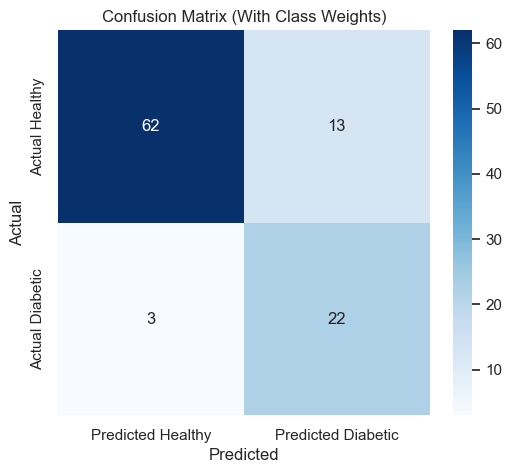


--- MODEL WITHOUT CLASS WEIGHTS (FOR COMPARISON) ---
AI Model Accuracy: 93.0%
AUC-ROC Score: 0.950

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.99      0.95        75
    Diabetic       0.95      0.76      0.84        25

    accuracy                           0.93       100
   macro avg       0.94      0.87      0.90       100
weighted avg       0.93      0.93      0.93       100



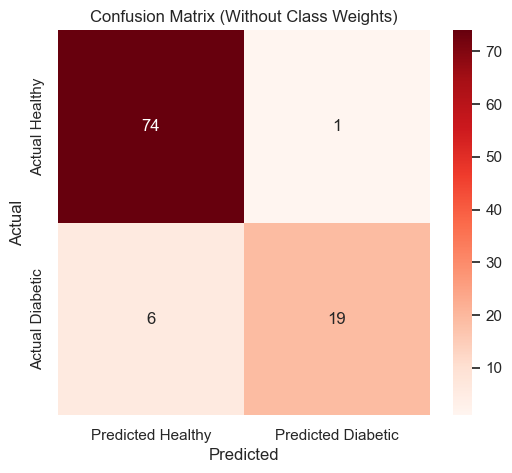

In [ ]:
# Approach 1: Using Class Weights (RECOMMENDED)

# Initialize and Train with class weights
# 'balanced' automatically adjusts weights inversely proportional to class frequencies

lr_model_weighted = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_model_weighted.fit(X_train, y_train)


# Make Predictions on the Exam data (X_test)
y_pred_weighted = lr_model_weighted.predict(X_test)
y_pred_proba_weighted = lr_model_weighted.predict_proba(X_test)[:, 1]

# Grade the Exam
acc_weighted = accuracy_score(y_test, y_pred_weighted)
auc_weighted = roc_auc_score(y_test, y_pred_proba_weighted)

print(f"\n--- MODEL WITH CLASS WEIGHTS ---")
print(f"AI Model Accuracy: {acc_weighted*100:.1f}%")
print(f"AUC-ROC Score: {auc_weighted:.3f} (Higher is better, 0.5 = random, 1.0 = perfect)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted, target_names=['Healthy', 'Diabetic']))

# The Confusion Matrix
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted Diabetic'],
            yticklabels=['Actual Healthy', 'Actual Diabetic'])
plt.title('Confusion Matrix (With Class Weights)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



#Approach 2: Without Class Weights (For Comparison)

# This shows what happens when we DON'T handle the imbalance
lr_model_no_weight = LogisticRegression(max_iter=1000)
lr_model_no_weight.fit(X_train, y_train)

y_pred_no_weight = lr_model_no_weight.predict(X_test)
y_pred_proba_no_weight = lr_model_no_weight.predict_proba(X_test)[:, 1]

acc_no_weight = accuracy_score(y_test, y_pred_no_weight)
auc_no_weight = roc_auc_score(y_test, y_pred_proba_no_weight)

print(f"\n--- MODEL WITHOUT CLASS WEIGHTS (FOR COMPARISON) ---")
print(f"AI Model Accuracy: {acc_no_weight*100:.1f}%")
print(f"AUC-ROC Score: {auc_no_weight:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_weight, target_names=['Healthy', 'Diabetic']))

cm_no_weight = confusion_matrix(y_test, y_pred_no_weight)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_no_weight, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Healthy', 'Predicted Diabetic'],
            yticklabels=['Actual Healthy', 'Actual Diabetic'])
plt.title('Confusion Matrix (Without Class Weights)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Which should we choose?

We should Use class weights (Approach 1) for medical scenarios like diabetes detection because:

Missing a diabetic case is worse than a false alarm. A false alarm means the patient gets further testing; a missed case means they don't get treatment.

The AUC-ROC is identical (0.949) — both models discriminate equally well between classes.

Recall matters more than accuracy in healthcare. You would d rather catch all diabetics and have some false alarms than miss real cases.


The 4% accuracy drop (88% → 84%) is a worthwhile trade to increase diabetic detection from 72% to 88%.

In [ ]:
# 5.3 Deploying the AI on a New Patient with 'Fasting_Blood_Sugar' as a feature

# Scenario: A new patient, Mr. Chinedu, walks into the clinic.

#     Age: 55

#     BMI: 32.5 (Obese)

#     Blood Sugar: 145 (High)

#     Systolic BP: 135

# Does Mr. Chinedu have Diabetes? Let's ask our model (AI).



# Create Mr. Chinedu's Profile[Age, BMI, FBS, Systolic_BP]
# chinedu_vitals = pd.DataFrame([[55, 32.5, 145, 135]], columns=['Age', 'BMI', 'Fasting_Blood_Sugar', 'Systolic_BP'])

# # Predict
# diagnosis = lr_model_weighted.predict(chinedu_vitals)
# confidence = lr_model_weighted.predict_proba(chinedu_vitals)

# print("--- AI DIAGNOSTIC REPORT: MR. CHINEDU ---")
# if diagnosis[0] == 1:
#     print(f"Diagnosis: POSITIVE for Diabetes.")
#     print(f"AI Confidence: {confidence[0][1]*100:.1f}%")
#     print("Action: Needs HbA1c test and dietary counseling immediately.")
# else:
#     print(f"Diagnosis: NEGATIVE for Diabetes.")
#     print(f"AI Confidence: {confidence[0][0]*100:.1f}%")
#     print("Action: Routine annual checkup.")

## Comparing Multiple Models


--- MODEL COMPARISON ---


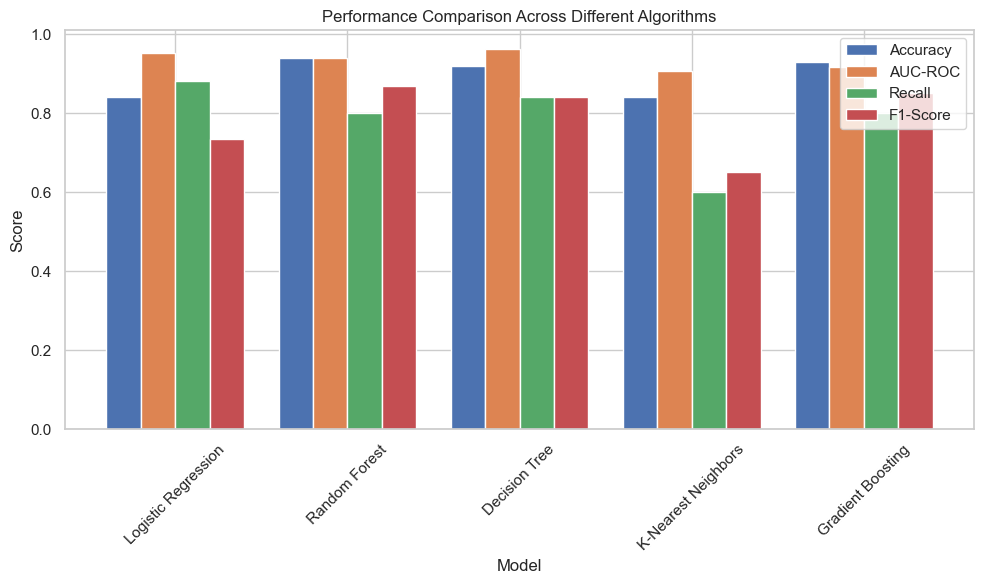


 **Best Model:** Decision Tree with AUC = 0.961


In [ ]:
## Step 5.4: Comparing Multiple Algorithms

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Define multiple models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5),
    'K-Nearest Neighbors': KNeighborsClassifier(weights='distance'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

# Train and evaluate all models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    }

# Create comparison table
comparison_df = pd.DataFrame(results).T
print("\n--- MODEL COMPARISON ---")
print(comparison_df.style.background_gradient(cmap='Greens').format('{:.3f}'))

# Visualize comparison
plt.figure(figsize=(10, 6))
metrics = ['Accuracy', 'AUC-ROC', 'Recall', 'F1-Score']
x = range(len(models))
width = 0.2

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in models.keys()]
    plt.bar([p + width*i for p in x], values, width, label=metric)

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Performance Comparison Across Different Algorithms')
plt.xticks([p + width*1.5 for p in x], list(models.keys()), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n **Best Model:** {max(results, key=lambda x: results[x]['AUC-ROC'])} with AUC = {results[max(results, key=lambda x: results[x]['AUC-ROC'])]['AUC-ROC']:.3f}")

## To make it more easier to understand, we can use the below code:

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Assuming X_train, X_test, y_train, y_test are already defined

# Model 1: Logistic Regression

# 1. Initialize the model
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)

# 2. Train the model
log_reg.fit(X_train, y_train)

# 3. Make predictions
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"Recall:   {classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall']:.3f}")
print(f"F1-Score: {classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score']:.3f}")
print("\n")




# Model 2: Random Forest

# 1. Initialize
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train
rf_model.fit(X_train, y_train)

# 3. Predict
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"Recall:   {classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']:.3f}")
print(f"F1-Score: {classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']:.3f}")
print("\n")



# Model 3: Decision Tree

# 1. Initialize
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=5)

# 2. Train
dt_model.fit(X_train, y_train)

# 3. Predict
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("--- Decision Tree ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba_dt):.3f}")
print(f"Recall:   {classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall']:.3f}")
print(f"F1-Score: {classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score']:.3f}")
print("\n")





# Model 4: K-Nearest Neighbors (KNN)

# 1. Initialize
knn_model = KNeighborsClassifier(weights='distance')

# 2. Train
knn_model.fit(X_train, y_train)

# 3. Predict
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("--- K-Nearest Neighbors ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba_knn):.3f}")
print(f"Recall:   {classification_report(y_test, y_pred_knn, output_dict=True)['1']['recall']:.3f}")
print(f"F1-Score: {classification_report(y_test, y_pred_knn, output_dict=True)['1']['f1-score']:.3f}")
print("\n")



# Model 5: Gradient Boosting

# 1. Initialize
gb_model = GradientBoostingClassifier(random_state=42, n_estimators=100)

# 2. Train
gb_model.fit(X_train, y_train)

# 3. Predict
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# 4. Evaluate
print("--- Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_proba_gb):.3f}")
print(f"Recall:   {classification_report(y_test, y_pred_gb, output_dict=True)['1']['recall']:.3f}")
print(f"F1-Score: {classification_report(y_test, y_pred_gb, output_dict=True)['1']['f1-score']:.3f}")
print("\n")




# Compare Results (Manual Table)


# Create a dictionary with the results manually
results_data = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'AUC-ROC': roc_auc_score(y_test, y_proba_lr),
        'Recall': classification_report(y_test, y_pred_lr, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred_lr, output_dict=True)['1']['f1-score']
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'AUC-ROC': roc_auc_score(y_test, y_proba_rf),
        'Recall': classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred_rf, output_dict=True)['1']['f1-score']
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'AUC-ROC': roc_auc_score(y_test, y_proba_dt),
        'Recall': classification_report(y_test, y_pred_dt, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred_dt, output_dict=True)['1']['f1-score']
    },
    'KNN': {
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'AUC-ROC': roc_auc_score(y_test, y_proba_knn),
        'Recall': classification_report(y_test, y_pred_knn, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred_knn, output_dict=True)['1']['f1-score']
    },
    'Gradient Boosting': {
        'Accuracy': accuracy_score(y_test, y_pred_gb),
        'AUC-ROC': roc_auc_score(y_test, y_proba_gb),
        'Recall': classification_report(y_test, y_pred_gb, output_dict=True)['1']['recall'],
        'F1-Score': classification_report(y_test, y_pred_gb, output_dict=True)['1']['f1-score']
    }
}

# Convert to DataFrame for a nice table view
comparison_df = pd.DataFrame(results_data).T
print("--- FINAL MODEL COMPARISON ---")
print(comparison_df.sort_values(by='AUC-ROC', ascending=False))



--- Logistic Regression ---
Accuracy: 0.840
AUC-ROC:  0.951
Recall:   0.880
F1-Score: 0.733


--- Random Forest ---
Accuracy: 0.940
AUC-ROC:  0.939
Recall:   0.800
F1-Score: 0.870


--- Decision Tree ---
Accuracy: 0.920
AUC-ROC:  0.961
Recall:   0.840
F1-Score: 0.840


--- K-Nearest Neighbors ---
Accuracy: 0.840
AUC-ROC:  0.906
Recall:   0.600
F1-Score: 0.652


--- Gradient Boosting ---
Accuracy: 0.930
AUC-ROC:  0.917
Recall:   0.800
F1-Score: 0.851


--- FINAL MODEL COMPARISON ---
                     Accuracy   AUC-ROC  Recall  F1-Score
Decision Tree            0.92  0.961067    0.84  0.840000
Logistic Regression      0.84  0.950933    0.88  0.733333
Random Forest            0.94  0.938667    0.80  0.869565
Gradient Boosting        0.93  0.917333    0.80  0.851064
KNN                      0.84  0.906133    0.60  0.652174


## Model Performance Analysis: Recall vs. F1-Score 

1. Understanding the Metrics in a Clinical Context 

Recall (Sensitivity): Measures the model's ability to find all positive cases. In this project, it answers: "Out of all patients who actually have Diabetes, how many did the AI catch?"

Why it matters: High Recall is critical in healthcare because missing a diabetic patient (a False Negative) can delay treatment and worsen outcomes.
         
**F1-Score:** The harmonic mean of Precision and Recall. It measures the model's balance.

**Why it matters:** It ensures the model is not just guessing everyone is sick to get a high Recall. A high F1-Score means the model is both accurate and reliable.
         
     

2. Interpreting Our Results 

Logistic Regression (Recall: 0.88): This model is the safest. It caught 88% of all diabetic patients. While its F1-Score is lower (0.73) due to a higher rate of false alarms, it minimizes the risk of missing a diagnosis.

Decision Tree (F1-Score: 0.84, AUC: 0.96): This model is the smartest. It shows excellent balance (High F1) and ranking power (High AUC). It is slightly more efficient than Logistic Regression, triggering fewer unnecessary tests while still maintaining strong detection capabilities.

Random Forest (F1-Score: 0.87): Similar to the Decision Tree, offering a very strong balance between catching cases and avoiding false alarms.
     

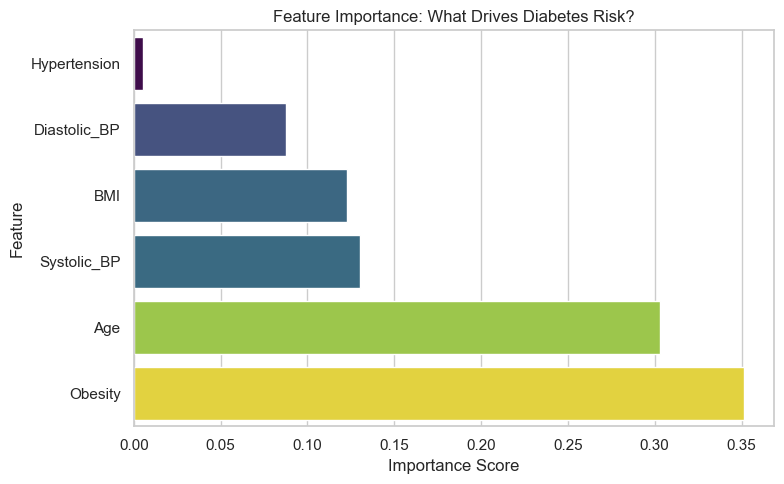


Feature Importance Ranking:
Hypertension: 0.005
Diastolic_BP: 0.088
BMI: 0.123
Systolic_BP: 0.130
Age: 0.303
Obesity: 0.351


In [ ]:
## Step 5.5: Understanding What Drives Diabetes Risk

# For Decision tree (interpretable feature importance)
dt_model = DecisionTreeClassifier( class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis', hue='Importance', legend=False)
plt.title('Feature Importance: What Drives Diabetes Risk?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for _, row in feature_importance.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.3f}")

In [ ]:
## Step 5.6: Saving Your Model for Future Use

import joblib
import os

# 1. Create the directory if it doesn't exist
# This prevents a 'FileNotFoundError' if the 'models' folder hasn't been created yet
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Save the Decision tree model
joblib.dump(dt_model, 'models/diabetes_predictor.pkl')
print("Decision Tree Model saved successfully to 'models/diabetes_predictor.pkl'")

# 3. Load it back later (simulating deployment)
# This proves that we can save the model, turn off the computer, and load it back tomorrow
loaded_model = joblib.load('models/diabetes_predictor.pkl')
print("Model loaded successfully!")



Decision Tree Model saved successfully to 'models/diabetes_predictor.pkl'
Model loaded successfully!


# What is Cross-Validation? 

Imagine you are studying for a very important exam. 

The "Single Split" Way (What we did earlier):
You take one practice test. If that specific test happened to be easy, you might think you are a genius. If it was extremely hard, you might think you are failing. Your result depends heavily on which questions were on that specific test. 

The Cross-Validation Way:

Instead of one test, you take 5 different practice tests. 

You study 80% of the material and test on the remaining 20%. 
You repeat this 5 times, rotating the test section each time. 
Finally, you take the average score of all 5 tests. 

This average is much more reliable because it proves you know the material regardless of which questions were asked. It ensures your model didn't just "get lucky" with one specific split of data. 

Cross-validation is a technique that splits your data into multiple folds, trains the model on different combinations of those folds, and averages the results to get a more reliable estimate of model performance.


Cross-validation is a statistical method that:

1. Divides your dataset into k equal parts (typically 5 or 10 folds)
2.  Trains k different models, each using k-1 folds for training and 1 fold for testing
3.  Rotates which fold is used for testing each time
4.  Averages the performance metrics across all k iterations


In [ ]:
# Cross-Validation (More Reliable Testing)

from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# 1. Define the splitting strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run Cross-Validation on the Descision Tree model
cv_scores = cross_val_score(dt_model, X, y, cv=cv, scoring='roc_auc')

print(f"\n--- Decision tree Cross-Validation Results ---")
print(f"AUC Scores per fold: {np.round(cv_scores, 3)}") 

# Low deviation (e.g., +/- 0.01): The model is stable and reliable.
# High deviation (e.g., +/- 0.10): The model is unstable; it works great sometimes and fails others.
print(f"Mean AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})") 

if cv_scores.std() < 0.05:
    print("Result: The model is very stable and reliable.")
else:
    print("Result: The model's performance varies significantly.")


--- Decision tree Cross-Validation Results ---
AUC Scores per fold: [0.827 0.74  0.82  0.857 0.878]
Mean AUC: 0.824 (+/- 0.047)
Result: The model is very stable and reliable.


In [ ]:
## Common Mistakes Students Should Avoid

print("\n" + "="*60)
print("COMMON PITFALLS IN MEDICAL ML PROJECTS")
print("="*60)

print("""
1. Using Accuracy Alone → In imbalanced data, accuracy is misleading
   Solution: Use AUC-ROC, Recall, F1-Score

2. Data Leakage → Using future information to predict the past
   Solution: Always split data BEFORE any preprocessing

3. Overfitting → Model memorizes training data, fails on new patients
   Solution: Use cross-validation, limit model complexity

4. Ignoring Class Imbalance → Model biased toward majority class
   Solution: Use class_weight='balanced' or SMOTE

5. Not Validating Clinically → Statistically good ≠ medically useful
   Solution: Consult domain experts (if not knowlegible), check false negatives

6. Forgetting to Check Assumptions → Normality, independence, etc.
   Solution: Always run statistical tests (like we did in Step 3)
""")


COMMON PITFALLS IN MEDICAL ML PROJECTS

1. Using Accuracy Alone → In imbalanced data, accuracy is misleading
   Solution: Use AUC-ROC, Recall, F1-Score

2. Data Leakage → Using future information to predict the past
   Solution: Always split data BEFORE any preprocessing

3. Overfitting → Model memorizes training data, fails on new patients
   Solution: Use cross-validation, limit model complexity

4. Ignoring Class Imbalance → Model biased toward majority class
   Solution: Use class_weight='balanced' or SMOTE

5. Not Validating Clinically → Statistically good ≠ medically useful
   Solution: Consult domain experts (if not knowlegible), check false negatives

6. Forgetting to Check Assumptions → Normality, independence, etc.
   Solution: Always run statistical tests (like we did in Step 3)



## Key Notes

1. **Accuracy is misleading** - A model that always predicts "Healthy" would get 75% accuracy but be useless!
2. **Use multiple metrics** - Better to always check Precision, Recall, F1-Score, and AUC-ROC
3. **Recall is crucial** - As it allows us to catch as many diabetic cases as possible (high Recall)
4. **Class weights help** - They make the model pay more attention to the minority class



## A ROC Curve (Receiver Operating Characteristic Curve):

is a graph that shows how well your classification model performs across all possible decision thresholds. It visualizes the trade-off between catching true positives and avoiding false positives.


## AUC (Area Under the Curve):

AUC (Area Under the Curve) is a single number (0 to 1) that summarizes the entire ROC curve:

AUC Score	    Interpretation

0.90–1.00:	    Excellent discrimination

0.80–0.90:	    Good discrimination

0.70–0.80:	    Fair discrimination

0.60–0.69:	    Poor discrimination

0.50:	        No discrimination (random guessing)
     

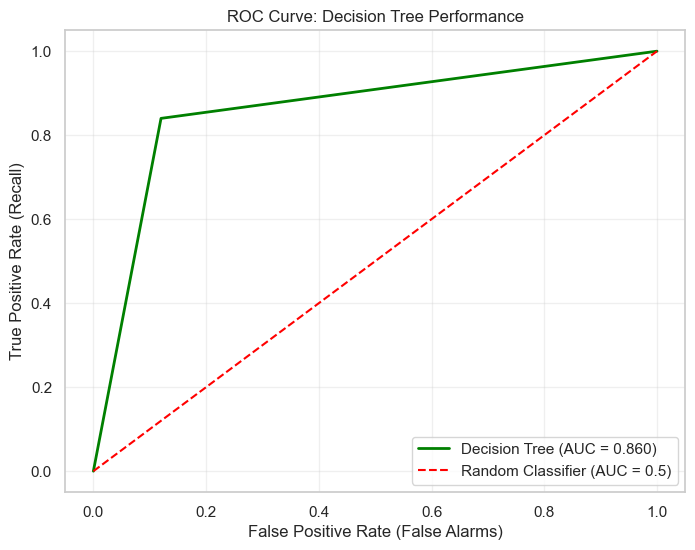

 Conclusion: Strong performance! The model has an AUC of 0.860.


In [ ]:
# # Visualising the ROC Curve

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# --- Step 1: Get Probabilities for the Random Forest Model ---
# We only need the probability of the positive class (Diabetes = 1)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# --- Step 2: Calculate ROC Curve points ---
# This calculates the False Positive Rate (fpr) and True Positive Rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dt)
roc_auc = auc(fpr, tpr)

# --- Step 3: Plot the Chart ---
plt.figure(figsize=(8, 6))

# Plot Decision Tree Curve
plt.plot(fpr, tpr, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc:.3f})')

# Plot the "Random Guess" Baseline (Dotted Line)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier (AUC = 0.5)')

# Add Labels and Title
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve: Decision Tree Performance')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()

# --- Step 4: Conclusion ---
if roc_auc > 0.8:
    print(f" Conclusion: Strong performance! The model has an AUC of {roc_auc:.3f}.")
else:
    print(f" Conclusion: The model has an AUC of {roc_auc:.3f}. Consider tuning parameters.")

## New Patient Profile

Age: 55

BMI: 32.5

Systolic_BP: 135

Diastolic_BP: 85

Hypertension: 0 (Since 135/85 is not technically > 140/90)

Obesity: 1 (Since BMI 32.5 is > 30)
     

Does Mr. Chinedu have Diabetes? Let's ask our model (AI).

In [ ]:
# Create Mr. Chinedu's Profile matching the new features
# Order: [Age, BMI, Systolic_BP, Diastolic_BP, Hypertension, Obesity]
chinedu_vitals = pd.DataFrame([[55, 32.5, 135, 85, 0, 1]], 
                              columns=['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Hypertension', 'Obesity'])

# Predict using the loaded model
diagnosis = loaded_model.predict(chinedu_vitals)
confidence = loaded_model.predict_proba(chinedu_vitals)

print("--- Model AI DIAGNOSTIC REPORT: MR. CHINEDU ---")
if diagnosis[0] == 1:
    print(f"Diagnosis: HIGH RISK for Diabetes.")
    print(f"AI Confidence: {confidence[0][1]*100:.1f}%")
    print("Action: Recommend Fasting Blood Sugar test immediately.")
else:
    print(f"Diagnosis: LOW RISK for Diabetes.")
    print(f"AI Confidence: {confidence[0][0]*100:.1f}%")
    print("Action: Routine checkup advised.")

--- Model AI DIAGNOSTIC REPORT: MR. CHINEDU ---
Diagnosis: LOW RISK for Diabetes.
AI Confidence: 100.0%
Action: Routine checkup advised.
